In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [17]:
df = pd.read_csv('./dummy_silver_data.csv')
df.head()

,location_id,sensor_id,location_name,datetime_utc,lat,lon,parameter,value,unit
0,AU001,S0001,Sydney - Rozelle,2026-08-06T00:00:00Z,-33.8608,151.1719,o3,8.59,µg/m³
1,AU001,S0001,Sydney - Rozelle,2026-08-06T00:00:00Z,-33.8608,151.1719,no2,17.90,µg/m³
2,AU001,S0001,Sydney - Rozelle,2026-08-06T00:00:00Z,-33.8608,151.1719,pm25,9.06,µg/m³
3,AU001,S0001,Sydney - Rozelle,2026-08-06T01:00:00Z,-33.8608,151.1719,o3,17.31,µg/m³
4,AU001,S0001,Sydney - Rozelle,2026-08-06T01:00:00Z,-33.8608,151.1719,no2,20.44,µg/m³


In [18]:
SILVER_COLUMNS = [
    "location_id",
    "sensor_id",
    "location_name",
    "datetime_utc",
    "lat",
    "lon",
    "parameter",
    "value",
    "unit",
]

df.columns

Index(['location_id', 'sensor_id', 'location_name', 'datetime_utc', 'lat',
       'lon', 'parameter', 'value', 'unit'],
      dtype='str')

In [19]:
# Check whether all expected columns are available

missing_columns = set(SILVER_COLUMNS) - set(df.columns)

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("All expected Silver columns are available.")

All expected Silver columns are available.


In [20]:
df.shape

(16176, 9)

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16176 entries, 0 to 16175
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   location_id    16176 non-null  str    
 1   sensor_id      16176 non-null  str    
 2   location_name  16176 non-null  str    
 3   datetime_utc   16176 non-null  str    
 4   lat            16176 non-null  float64
 5   lon            16176 non-null  float64
 6   parameter      16176 non-null  str    
 7   value          16123 non-null  float64
 8   unit           16176 non-null  str    
dtypes: float64(3), str(6)
memory usage: 1.1 MB


In [22]:
df.head(10)

,location_id,sensor_id,location_name,datetime_utc,lat,lon,parameter,value,unit
0,AU001,S0001,Sydney - Rozelle,2026-08-06T00:00:00Z,-33.8608,151.1719,o3,8.59,µg/m³
1,AU001,S0001,Sydney - Rozelle,2026-08-06T00:00:00Z,-33.8608,151.1719,no2,17.90,µg/m³
2,AU001,S0001,Sydney - Rozelle,2026-08-06T00:00:00Z,-33.8608,151.1719,pm25,9.06,µg/m³
3,AU001,S0001,Sydney - Rozelle,2026-08-06T01:00:00Z,-33.8608,151.1719,o3,17.31,µg/m³
4,AU001,S0001,Sydney - Rozelle,2026-08-06T01:00:00Z,-33.8608,151.1719,no2,20.44,µg/m³
5,AU001,S0001,Sydney - Rozelle,2026-08-06T01:00:00Z,-33.8608,151.1719,pm25,8.05,µg/m³
6,AU001,S0001,Sydney - Rozelle,2026-08-06T02:00:00Z,-33.8608,151.1719,o3,39.26,µg/m³
7,AU001,S0001,Sydney - Rozelle,2026-08-06T02:00:00Z,-33.8608,151.1719,no2,31.51,µg/m³
8,AU001,S0001,Sydney - Rozelle,2026-08-06T02:00:00Z,-33.8608,151.1719,pm25,10.47,µg/m³
9,AU001,S0001,Sydney - Rozelle,2026-08-06T03:00:00Z,-33.8608,151.1719,o3,32.79,µg/m³


In [23]:
df.tail(10)

,location_id,sensor_id,location_name,datetime_utc,lat,lon,parameter,value,unit
16166,AU008,S0021,Darwin - Palmerston,2026-08-19T21:00:00Z,-12.4855,130.982,no2,22.60,µg/m³
16167,AU008,S0021,Darwin - Palmerston,2026-08-19T22:00:00Z,-12.4855,130.982,pm10,23.42,µg/m³
16168,AU008,S0021,Darwin - Palmerston,2026-08-19T22:00:00Z,-12.4855,130.982,so2,7.53,µg/m³
16169,AU008,S0021,Darwin - Palmerston,2026-08-19T22:00:00Z,-12.4855,130.982,no2,28.31,µg/m³
16170,AU008,S0021,Darwin - Palmerston,2026-08-19T23:00:00Z,-12.4855,130.982,pm10,17.16,µg/m³
16171,AU008,S0021,Darwin - Palmerston,2026-08-19T23:00:00Z,-12.4855,130.982,so2,5.74,µg/m³
16172,AU008,S0021,Darwin - Palmerston,2026-08-19T23:00:00Z,-12.4855,130.982,no2,38.36,µg/m³
16173,AU008,S0021,Darwin - Palmerston,2026-08-20T00:00:00Z,-12.4855,130.982,pm10,9.87,µg/m³
16174,AU008,S0021,Darwin - Palmerston,2026-08-20T00:00:00Z,-12.4855,130.982,so2,7.29,µg/m³
16175,AU008,S0021,Darwin - Palmerston,2026-08-20T00:00:00Z,-12.4855,130.982,no2,30.73,µg/m³


In [24]:
df.sample(5)

,location_id,sensor_id,location_name,datetime_utc,lat,lon,parameter,value,unit
3051,AU002,S0004,Melbourne - CBD,2026-08-06T06:00:00Z,-37.8136,144.9631,pm10,6.99,µg/m³
5487,AU003,S0007,Brisbane - South,2026-08-07T23:00:00Z,-27.4820,153.0175,no2,13.83,µg/m³
13093,AU007,S0018,Hobart - New Town,2026-08-11T23:00:00Z,-42.8613,147.3080,co,89.90,µg/m³
10487,AU006,S0014,Canberra - Civic,2026-08-13T20:00:00Z,-35.2809,149.1300,pm10,10.56,µg/m³
10972,AU006,S0015,Canberra - Civic,2026-08-09T22:00:00Z,-35.2809,149.1300,no2,1.84,µg/m³


In [25]:
df.dtypes

location_id          str
sensor_id            str
location_name        str
datetime_utc         str
lat              float64
lon              float64
parameter            str
value            float64
unit                 str
dtype: object

In [26]:
df["datetime_utc"] = pd.to_datetime(df["datetime_utc"], errors="coerce")
df["value"] = pd.to_numeric(df["value"], errors="coerce")

df.dtypes

location_id                      str
sensor_id                        str
location_name                    str
datetime_utc     datetime64[us, UTC]
lat                          float64
lon                          float64
parameter                        str
value                        float64
unit                             str
dtype: object

In [27]:
# Check missing values and duplicated rows

print("Duplicate rows:", df.duplicated().sum())
print("Missing values:")
print(df.isnull().sum())

Duplicate rows: 0
Missing values:
location_id       0
sensor_id         0
location_name     0
datetime_utc      0
lat               0
lon               0
parameter         0
value            53
unit              0
dtype: int64


In [28]:
df["parameter"].value_counts()

parameter
o3      2696
no2     2696
pm25    2696
so2     2696
pm10    2696
co      2696
Name: count, dtype: int64

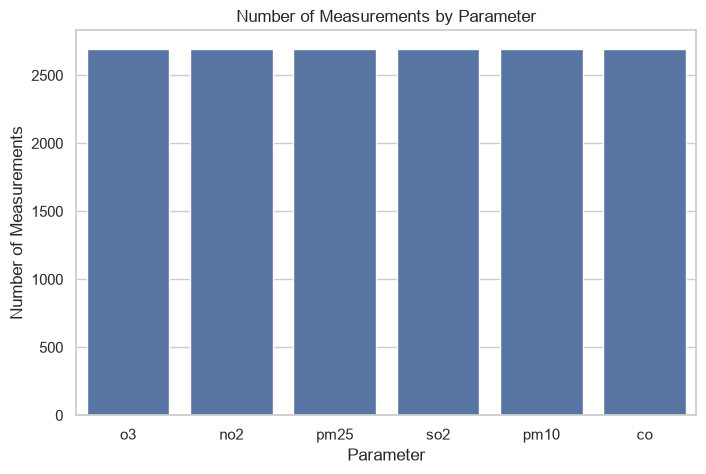

In [29]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="parameter",
    order=df["parameter"].value_counts().index
)

plt.title("Number of Measurements by Parameter")
plt.xlabel("Parameter")
plt.ylabel("Number of Measurements")
plt.show()

In [30]:
df.groupby("parameter")["unit"].unique()

parameter
co      [µg/m³]
no2     [µg/m³]
o3      [µg/m³]
pm10    [µg/m³]
pm25    [µg/m³]
so2     [µg/m³]
Name: unit, dtype: object

In [31]:
df["unit"].value_counts()

unit
µg/m³    16176
Name: count, dtype: int64

In [32]:
# Location and Sensor Coverage

print("Unique locations:", df["location_id"].nunique())
print("Unique sensors:", df["sensor_id"].nunique())

Unique locations: 8
Unique sensors: 21


In [33]:
location_counts = (
    df["location_name"]
    .value_counts()
    .head(15)
)

location_counts

location_name
Sydney - Rozelle       2022
Melbourne - CBD        2022
Brisbane - South       2022
Perth - Swanbourne     2022
Adelaide - Netley      2022
Canberra - Civic       2022
Hobart - New Town      2022
Darwin - Palmerston    2022
Name: count, dtype: int64

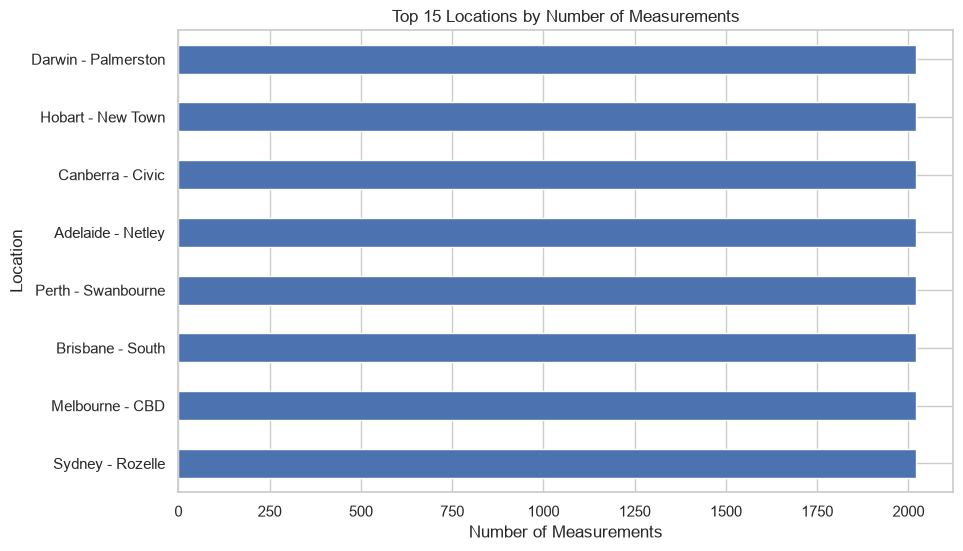

In [34]:
plt.figure(figsize=(10, 6))

location_counts.sort_values().plot(kind="barh")

plt.title("Top 15 Locations by Number of Measurements")
plt.xlabel("Number of Measurements")
plt.ylabel("Location")

plt.show()

In [35]:
sensor_parameter_counts = (
    df.groupby(["parameter", "sensor_id"])
      .size()
      .reset_index(name="count")
)

sensor_parameter_counts.head()

,parameter,sensor_id,count
0,co,S0002,337
1,co,S0003,337
2,co,S0007,337
3,co,S0010,337
4,co,S0012,337


In [36]:
sensor_parameter_counts.shape

(48, 3)

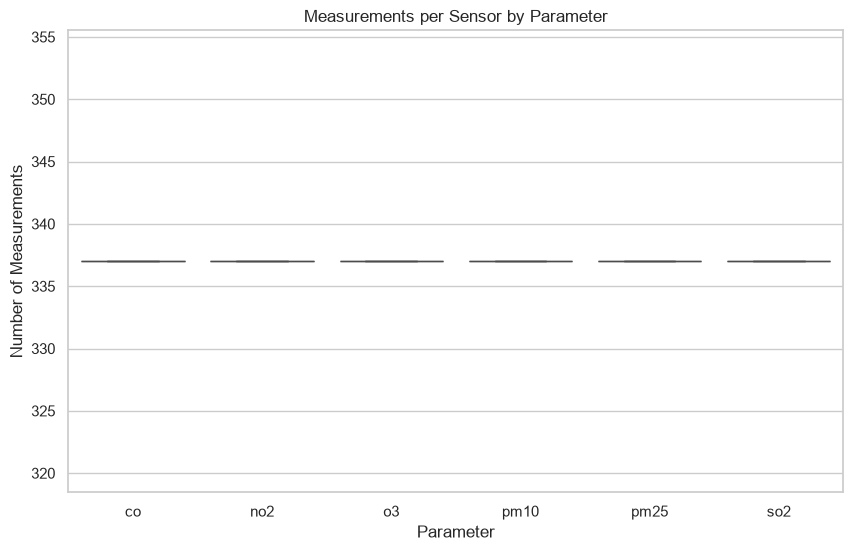

In [37]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=sensor_parameter_counts,
    x="parameter",
    y="count"
)

plt.title("Measurements per Sensor by Parameter")
plt.xlabel("Parameter")
plt.ylabel("Number of Measurements")

plt.show()

In [38]:
# Temporal Coverage
print("Start date:", df["datetime_utc"].min())
print("End date:", df["datetime_utc"].max())

print(
    "Number of days:",
    (df["datetime_utc"].max() - df["datetime_utc"].min()).days
)

Start date: 2026-08-06 00:00:00+00:00
End date: 2026-08-20 00:00:00+00:00
Number of days: 14


In [40]:
df["date"] = df["datetime_utc"].dt.date

daily_counts = df.groupby("date").size()

daily_counts

date
2026-08-06    1152
2026-08-07    1152
2026-08-08    1152
2026-08-09    1152
2026-08-10    1152
2026-08-11    1152
2026-08-12    1152
2026-08-13    1152
2026-08-14    1152
2026-08-15    1152
2026-08-16    1152
2026-08-17    1152
2026-08-18    1152
2026-08-19    1152
2026-08-20      48
dtype: int64

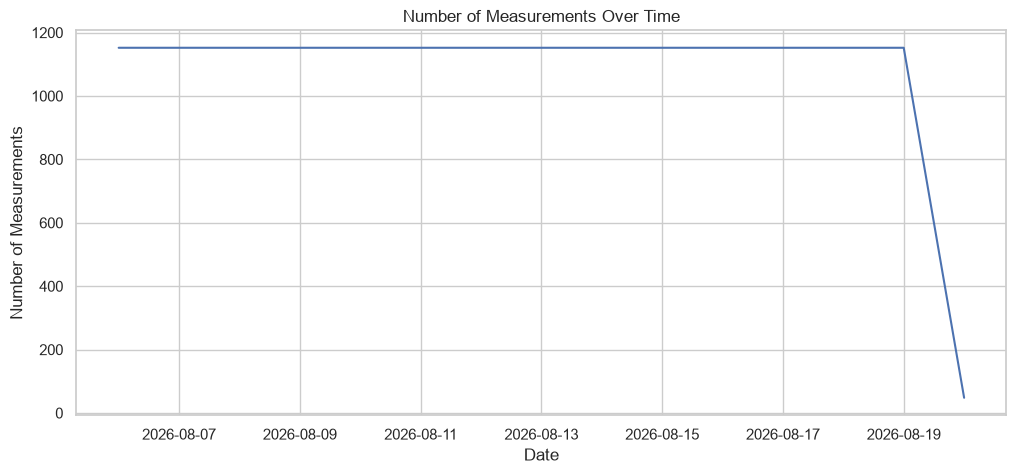

In [41]:
plt.figure(figsize=(12, 5))

daily_counts.plot()

plt.title("Number of Measurements Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Measurements")

plt.show()

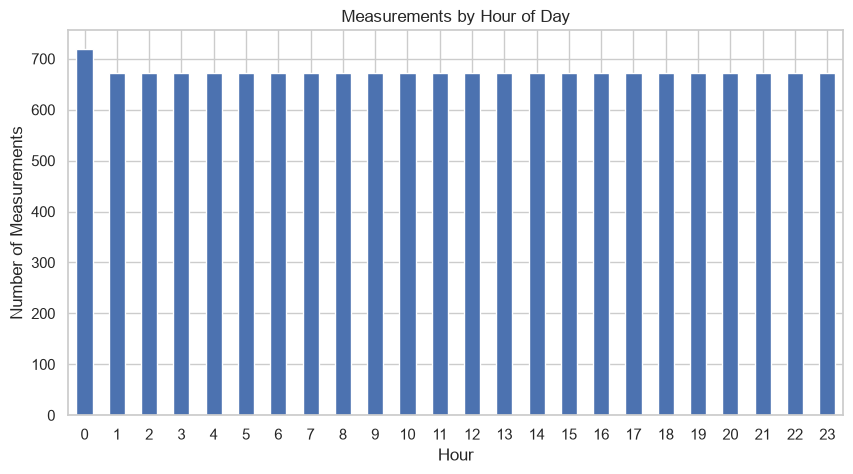

In [42]:
df["hour"] = df["datetime_utc"].dt.hour

hour_counts = df["hour"].value_counts().sort_index()

plt.figure(figsize=(10, 5))

hour_counts.plot(kind="bar")

plt.title("Measurements by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Measurements")

plt.xticks(rotation=0)

plt.show()

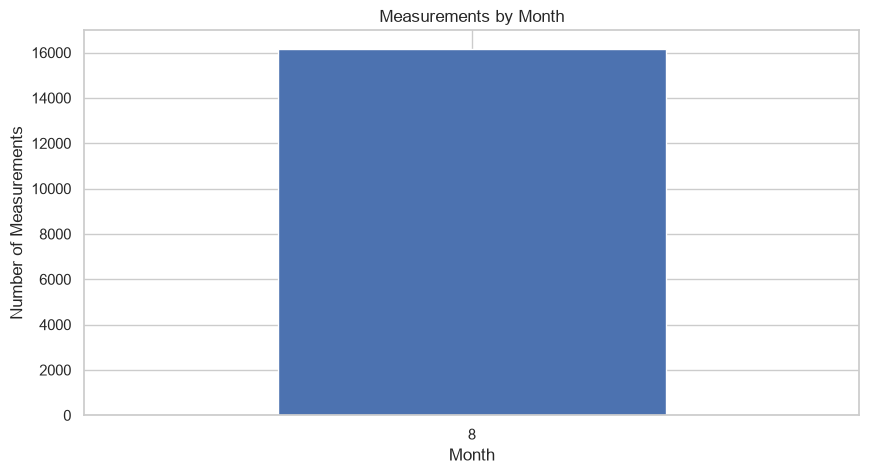

In [43]:
df["month"] = df["datetime_utc"].dt.month

month_counts = df["month"].value_counts().sort_index()

plt.figure(figsize=(10, 5))

month_counts.plot(kind="bar")

plt.title("Measurements by Month")
plt.xlabel("Month")
plt.ylabel("Number of Measurements")

plt.xticks(rotation=0)

plt.show()

In [44]:
# Pollution Statistics

pollution_stats = (
    df.groupby("parameter")["value"]
      .agg([
          "count",
          "mean",
          "median",
          "std",
          "min",
          "max"
      ])
      .round(2)
)

pollution_stats

,count,mean,median,std,min,max
parameter,,,,,,
co,2685,427.80,308.06,1972.42,-604.34,67445.0
no2,2690,31.18,22.63,130.92,-34.45,3020.0
o3,2689,62.64,49.75,235.46,-59.10,6919.0
pm10,2683,22.62,15.03,105.75,-26.18,2314.0
pm25,2691,13.75,7.78,83.00,-13.07,1956.0
so2,2685,6.48,5.06,29.31,-10.19,927.0


In [45]:
percentiles = (
    df.groupby("parameter")["value"]
      .quantile([0.25, 0.50, 0.75, 0.95, 0.99])
      .unstack()
      .round(2)
)

percentiles

,0.25,0.50,0.75,0.95,0.99
parameter,,,,,
co,182.64,308.06,437.07,638.27,828.75
no2,15.26,22.63,30.14,40.68,51.21
o3,37.11,49.75,62.94,82.05,99.93
pm10,10.45,15.03,19.58,26.62,33.60
pm25,4.94,7.78,10.73,15.18,20.03
so2,2.82,5.06,7.51,11.02,13.48


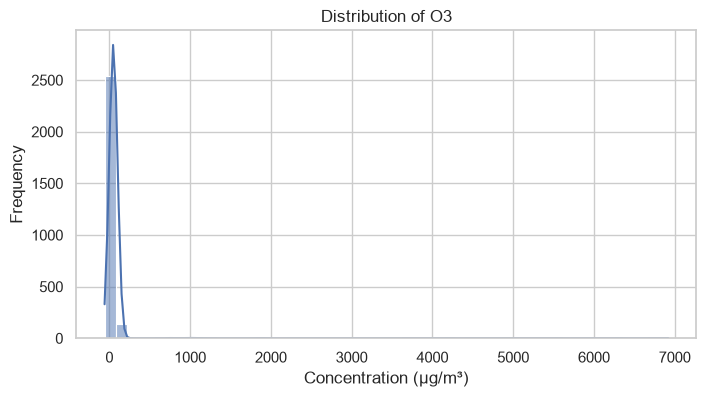

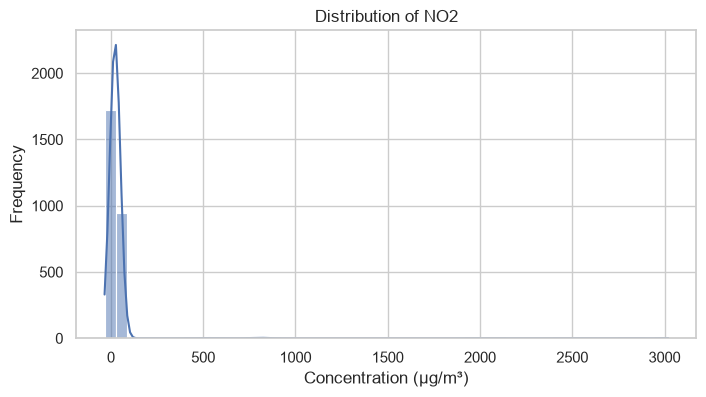

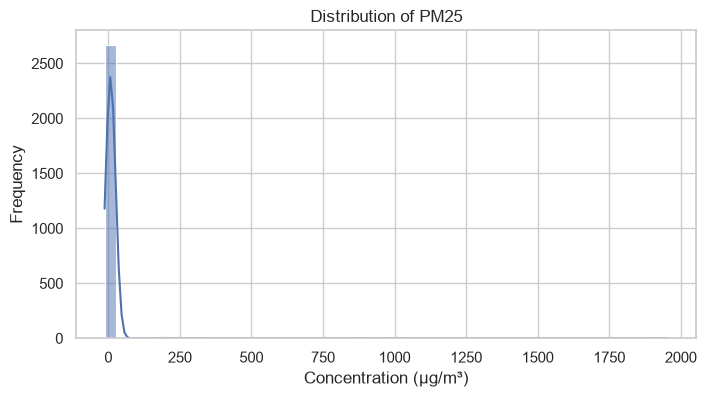

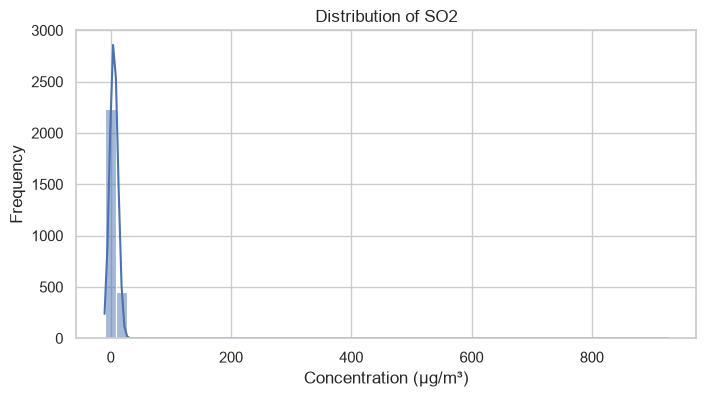

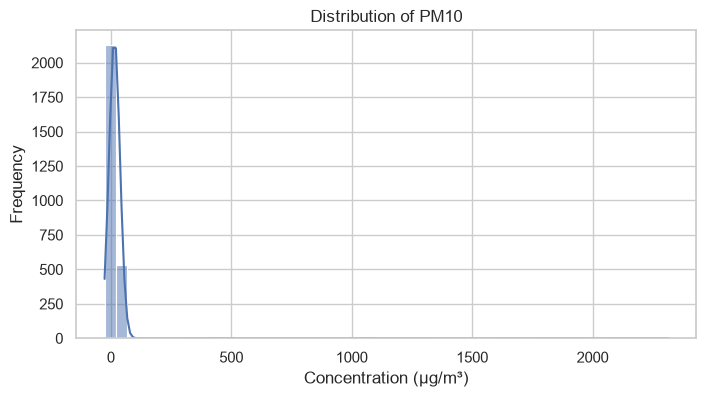

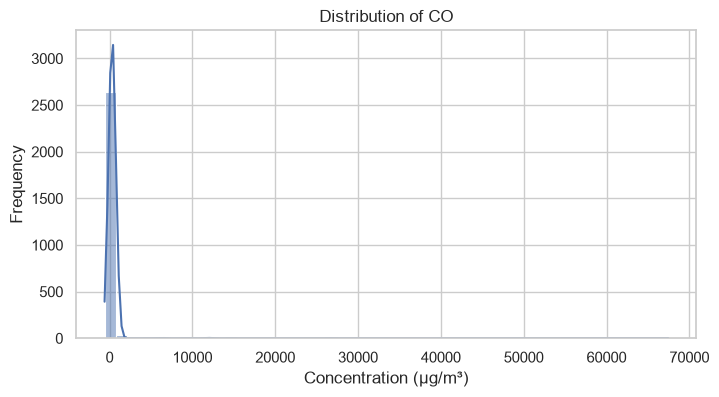

In [46]:
parameters = df["parameter"].dropna().unique()

for parameter in parameters:
    
    data = df.loc[df["parameter"] == parameter, "value"].dropna()
    
    plt.figure(figsize=(8, 4))
    
    sns.histplot(data, bins=50, kde=True)
    
    plt.title(f"Distribution of {parameter.upper()}")
    plt.xlabel("Concentration (µg/m³)")
    plt.ylabel("Frequency")
    
    plt.show()

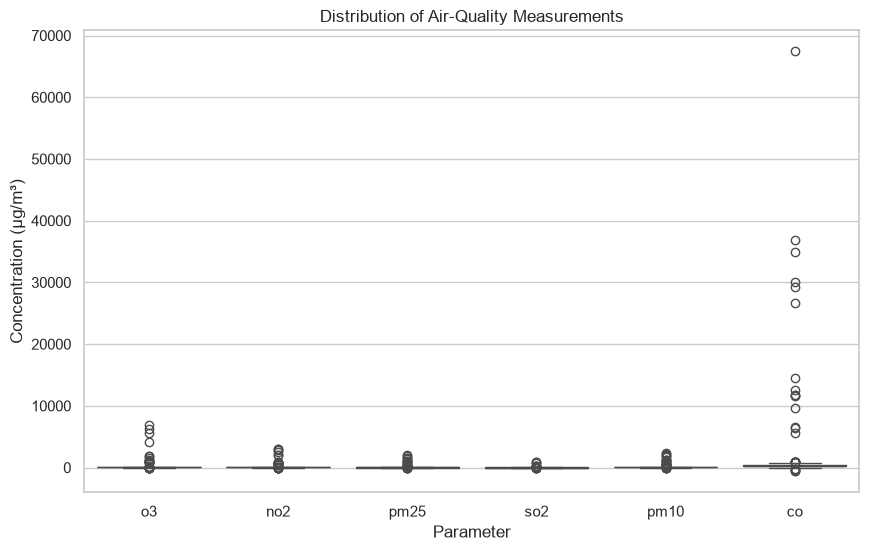

In [47]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="parameter",
    y="value"
)

plt.title("Distribution of Air-Quality Measurements")
plt.xlabel("Parameter")
plt.ylabel("Concentration (µg/m³)")

plt.show()

In [48]:
daily_pollution = (
    df.set_index("datetime_utc")
      .groupby("parameter")["value"]
      .resample("D")
      .mean()
      .reset_index()
)

daily_pollution.head()

,parameter,datetime_utc,value
0,co,2026-08-06 00:00:00+00:00,385.611518
1,co,2026-08-07 00:00:00+00:00,497.333021
2,co,2026-08-08 00:00:00+00:00,483.616510
3,co,2026-08-09 00:00:00+00:00,320.479263
4,co,2026-08-10 00:00:00+00:00,368.341885


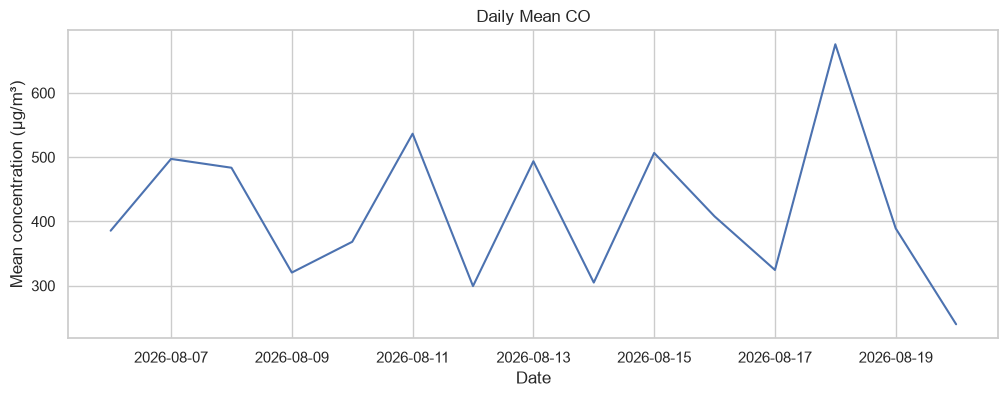

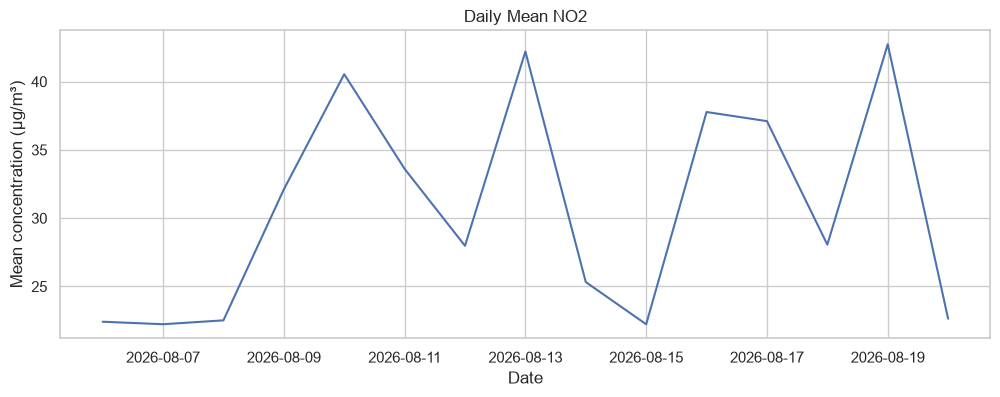

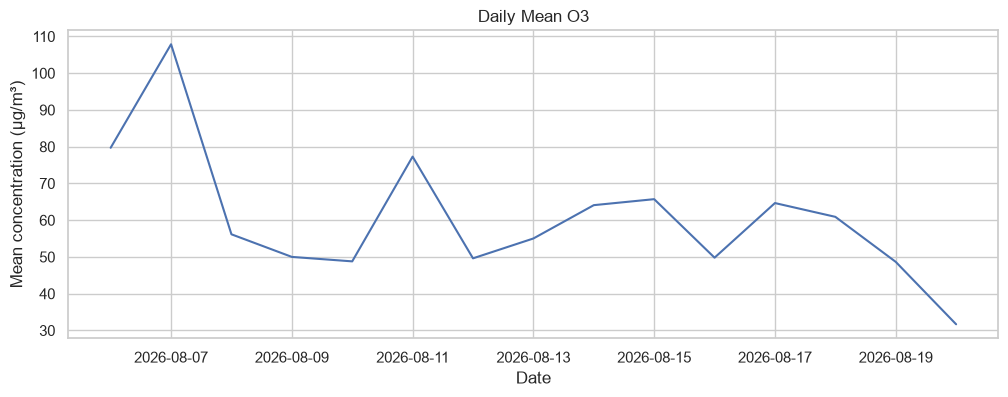

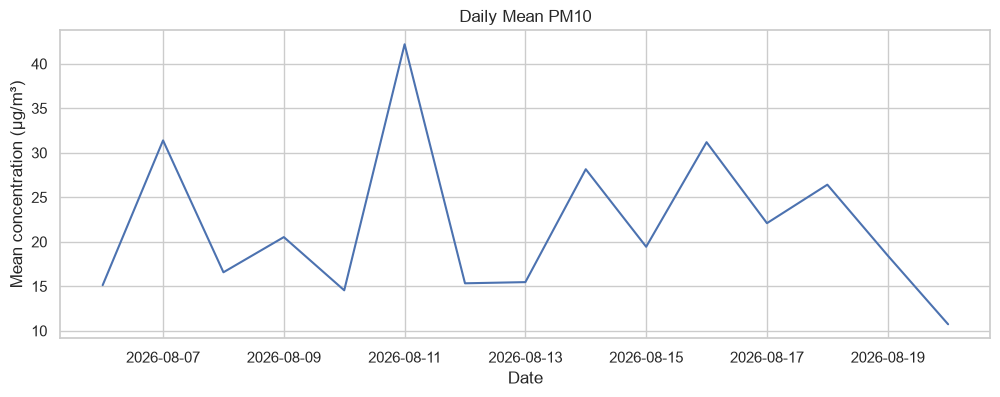

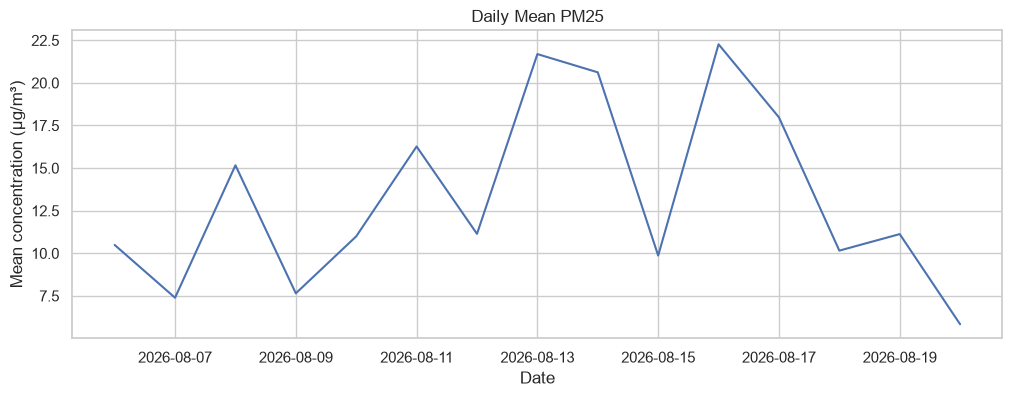

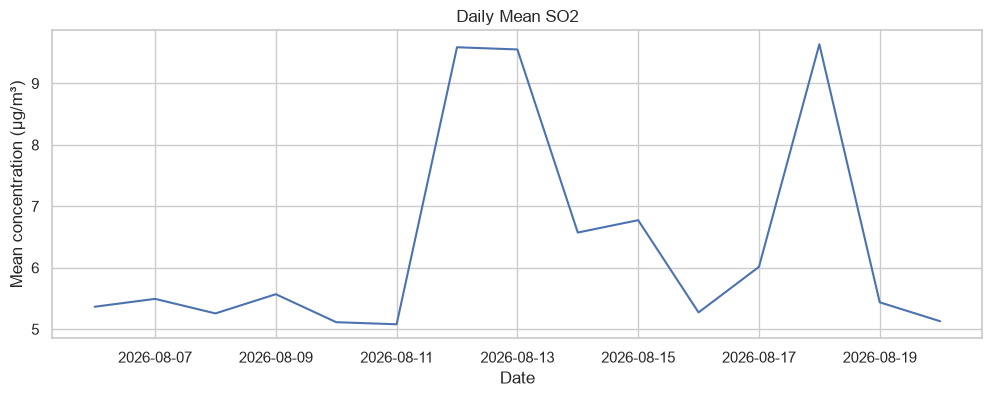

In [49]:
for parameter in daily_pollution["parameter"].unique():
    
    temp = daily_pollution[
        daily_pollution["parameter"] == parameter
    ]
    
    plt.figure(figsize=(12, 4))
    
    plt.plot(
        temp["datetime_utc"],
        temp["value"]
    )
    
    plt.title(f"Daily Mean {parameter.upper()}")
    plt.xlabel("Date")
    plt.ylabel("Mean concentration (µg/m³)")
    
    plt.show()

In [50]:
# 7-days rolling mean pattern

daily_pollution["rolling_7d"] = (
    daily_pollution
    .groupby("parameter")["value"]
    .transform(
        lambda x: x.rolling(7, min_periods=3).mean()
    )
)

daily_pollution.head()

,parameter,datetime_utc,value,rolling_7d
0,co,2026-08-06 00:00:00+00:00,385.611518,NaN
1,co,2026-08-07 00:00:00+00:00,497.333021,NaN
2,co,2026-08-08 00:00:00+00:00,483.616510,455.520350
3,co,2026-08-09 00:00:00+00:00,320.479263,421.760078
4,co,2026-08-10 00:00:00+00:00,368.341885,411.076440


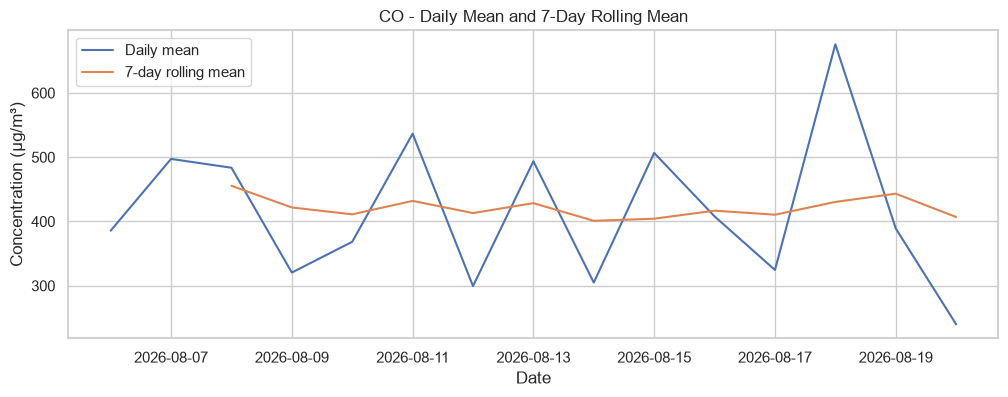

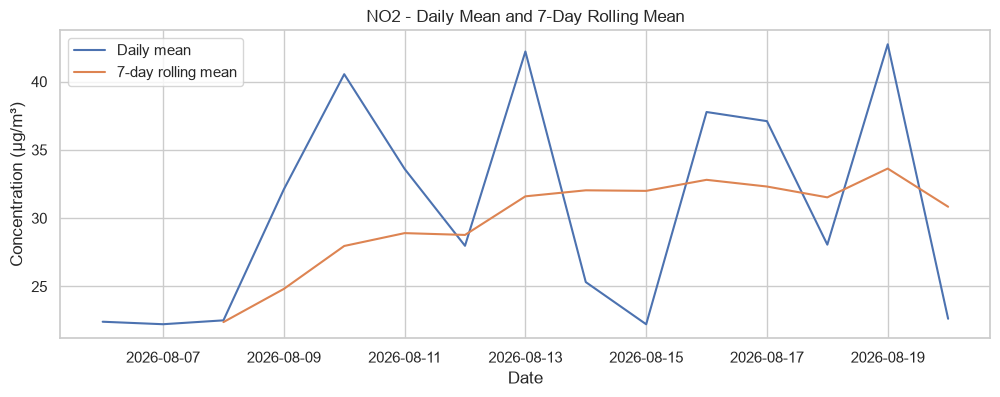

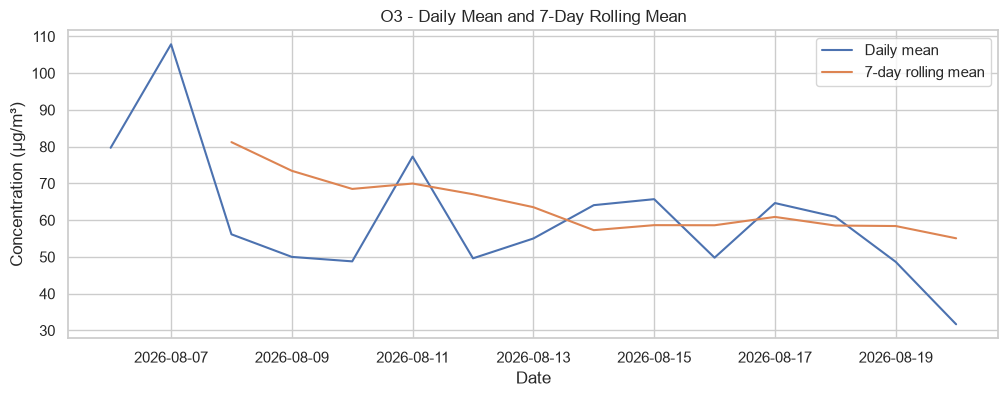

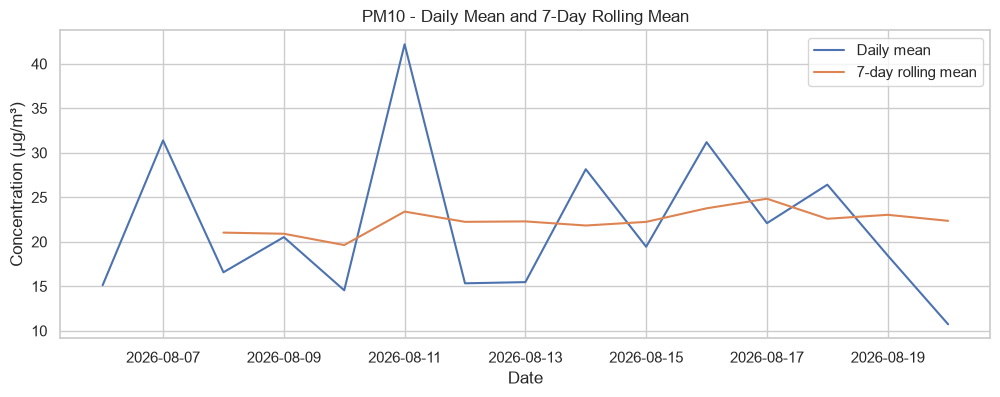

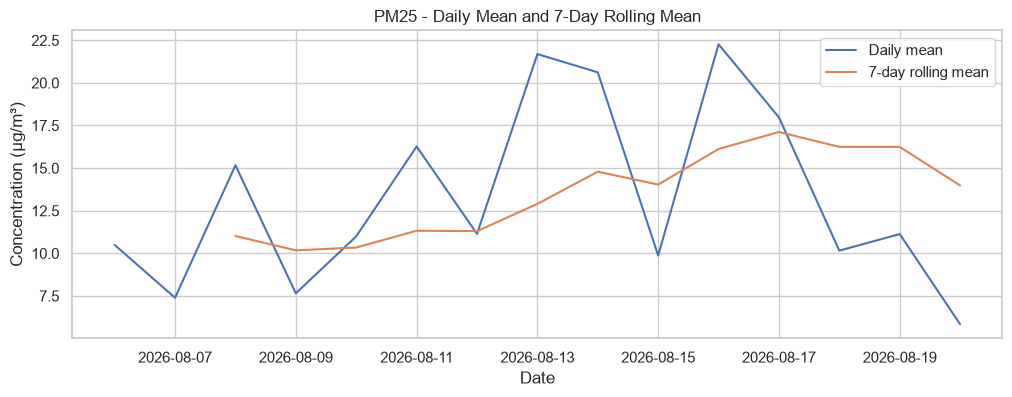

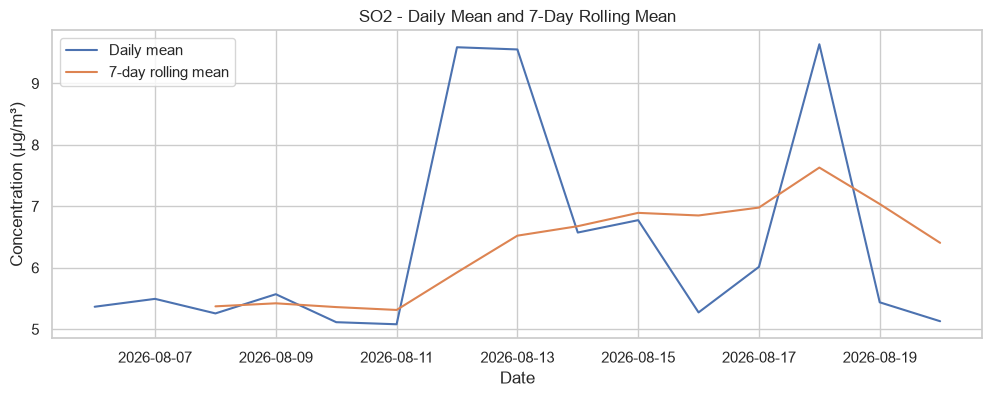

In [51]:
for parameter in daily_pollution["parameter"].unique():
    
    temp = daily_pollution[
        daily_pollution["parameter"] == parameter
    ]
    
    plt.figure(figsize=(12, 4))
    
    plt.plot(
        temp["datetime_utc"],
        temp["value"],
        label="Daily mean"
    )
    
    plt.plot(
        temp["datetime_utc"],
        temp["rolling_7d"],
        label="7-day rolling mean"
    )
    
    plt.title(f"{parameter.upper()} - Daily Mean and 7-Day Rolling Mean")
    plt.xlabel("Date")
    plt.ylabel("Concentration (µg/m³)")
    plt.legend()
    
    plt.show()

In [52]:
# Daily change
daily_pollution["daily_change"] = (
    daily_pollution
    .groupby("parameter")["value"]
    .diff()
)

daily_pollution.head()

,parameter,datetime_utc,value,rolling_7d,daily_change
0,co,2026-08-06 00:00:00+00:00,385.611518,NaN,NaN
1,co,2026-08-07 00:00:00+00:00,497.333021,NaN,111.721503
2,co,2026-08-08 00:00:00+00:00,483.616510,455.520350,-13.716510
3,co,2026-08-09 00:00:00+00:00,320.479263,421.760078,-163.137247
4,co,2026-08-10 00:00:00+00:00,368.341885,411.076440,47.862622


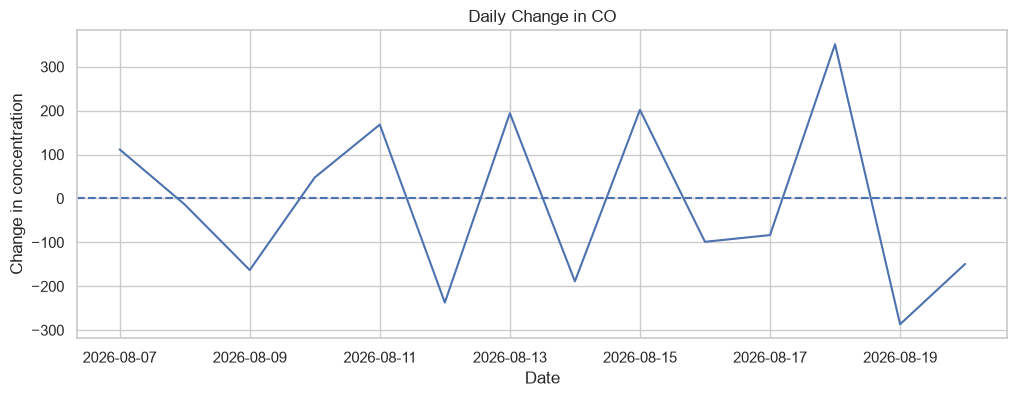

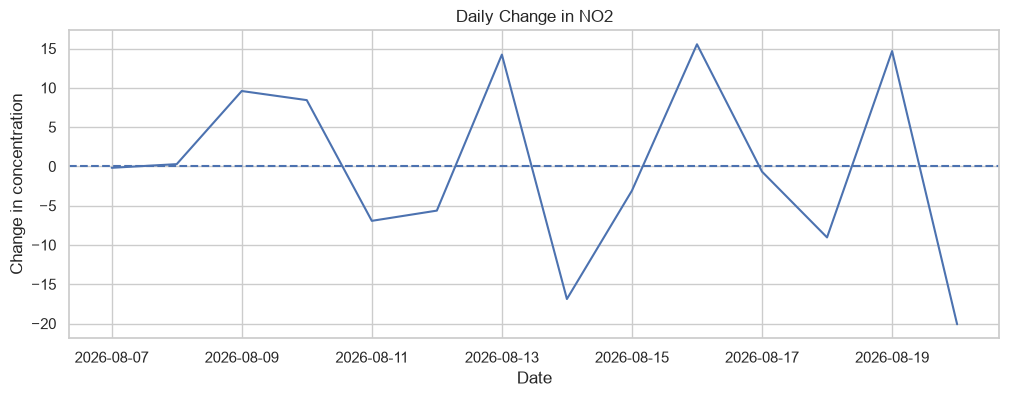

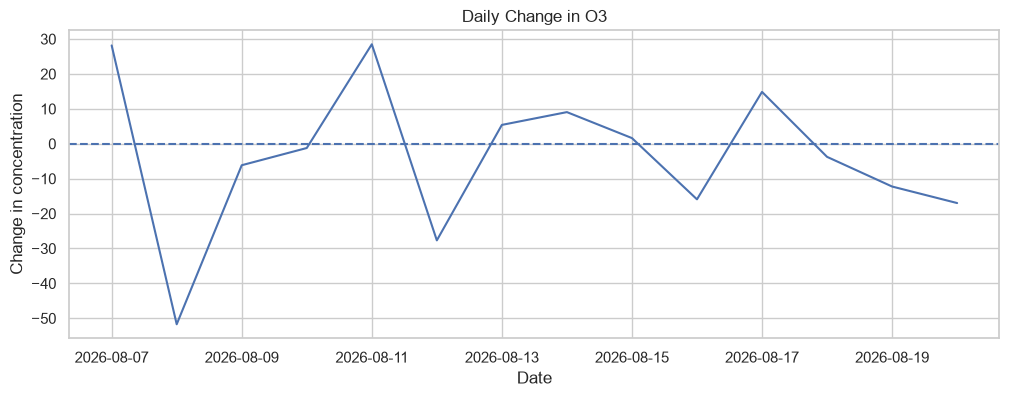

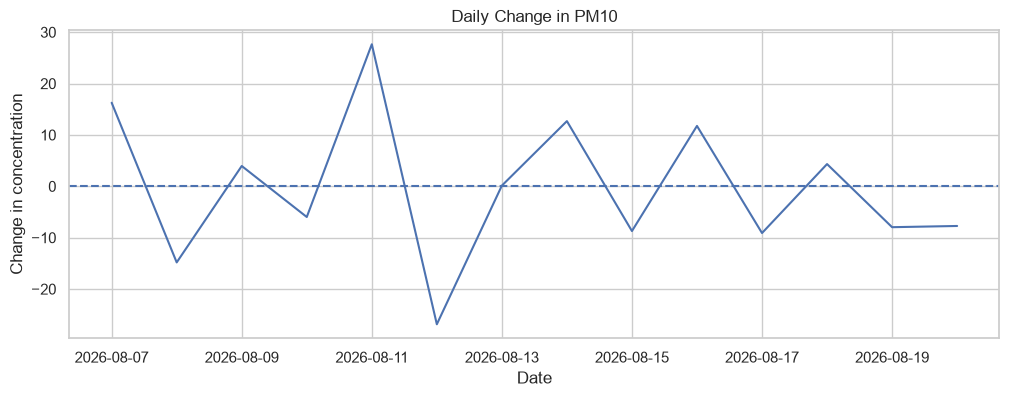

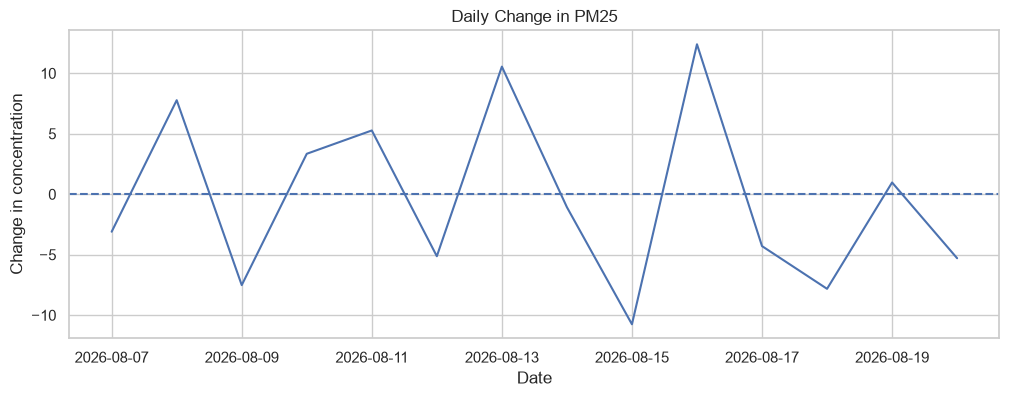

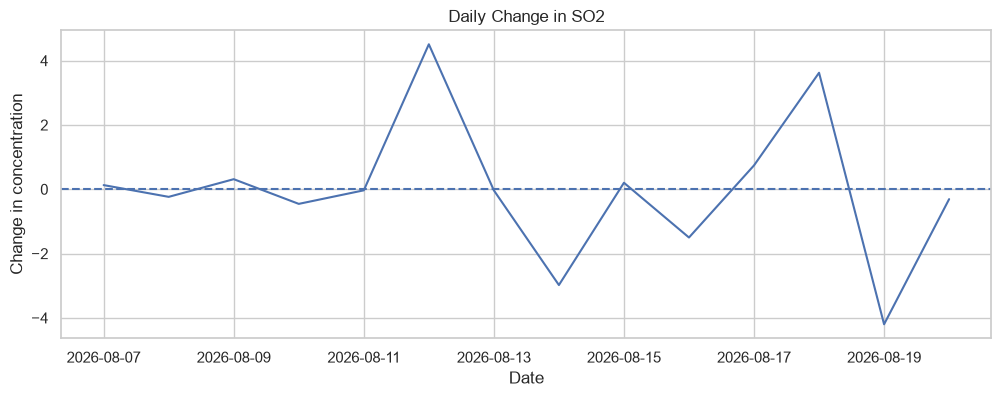

In [53]:
for parameter in daily_pollution["parameter"].unique():
    
    temp = daily_pollution[
        daily_pollution["parameter"] == parameter
    ]
    
    plt.figure(figsize=(12, 4))
    
    plt.plot(
        temp["datetime_utc"],
        temp["daily_change"]
    )
    
    plt.axhline(0, linestyle="--")
    
    plt.title(f"Daily Change in {parameter.upper()}")
    plt.xlabel("Date")
    plt.ylabel("Change in concentration")
    
    plt.show()

In [55]:
# Pollution levels by location
location_pollution = (
    df.groupby(["location_name", "parameter"])["value"]
      .mean()
      .reset_index()
)

location_pollution.head()

,location_name,parameter,value
0,Adelaide - Netley,co,434.677440
1,Adelaide - Netley,no2,32.666499
2,Adelaide - Netley,o3,51.055000
3,Adelaide - Netley,pm10,32.387827
4,Adelaide - Netley,pm25,13.163601


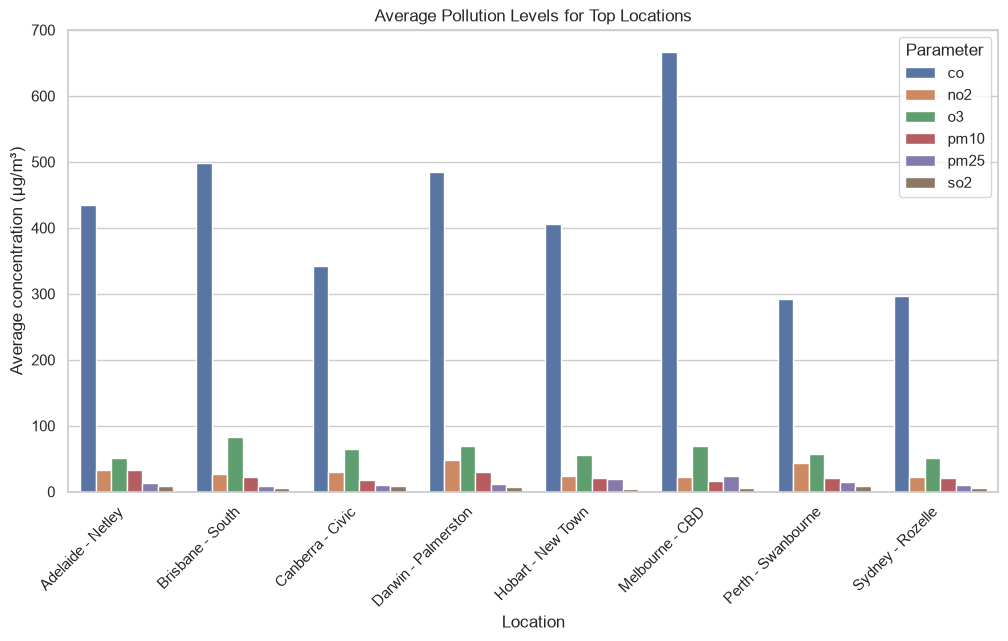

In [56]:
top_locations = (
    df["location_name"]
    .value_counts()
    .head(10)
    .index
)

temp = location_pollution[
    location_pollution["location_name"].isin(top_locations)
]

plt.figure(figsize=(12, 6))

sns.barplot(
    data=temp,
    x="location_name",
    y="value",
    hue="parameter"
)

plt.title("Average Pollution Levels for Top Locations")
plt.xlabel("Location")
plt.ylabel("Average concentration (µg/m³)")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Parameter")

plt.show()

In [57]:
# Pollution correlation
pollutant_wide = (
    df.pivot_table(
        index=["location_id", "datetime_utc"],
        columns="parameter",
        values="value",
        aggfunc="mean"
    )
)

pollutant_wide.head()

parameter                                  co    no2     o3  pm10   pm25   so2
location_id datetime_utc                                                      
AU001       2026-08-06 00:00:00+00:00   21.39  17.90   8.59  9.41   9.06  2.64
            2026-08-06 01:00:00+00:00  296.16  20.44  17.31  8.17   8.05  5.44
            2026-08-06 02:00:00+00:00  142.16  31.51  39.26  8.60  10.47  4.52
            2026-08-06 03:00:00+00:00  633.64   0.00  32.79  9.69   3.46  4.50
            2026-08-06 04:00:00+00:00    0.00  11.67  38.96  9.40   4.05  4.95

In [58]:
correlation = pollutant_wide.corr()

correlation.round(2)

parameter,co,no2,o3,pm10,pm25,so2
parameter,,,,,,
co,1.0,-0.00,0.0,-0.0,-0.0,0.00
no2,-0.0,1.00,-0.0,-0.0,-0.0,0.01
o3,0.0,-0.00,1.0,-0.0,-0.0,0.00
pm10,-0.0,-0.00,-0.0,1.0,-0.0,0.00
pm25,-0.0,-0.00,-0.0,-0.0,1.0,-0.00
so2,0.0,0.01,0.0,0.0,-0.0,1.00


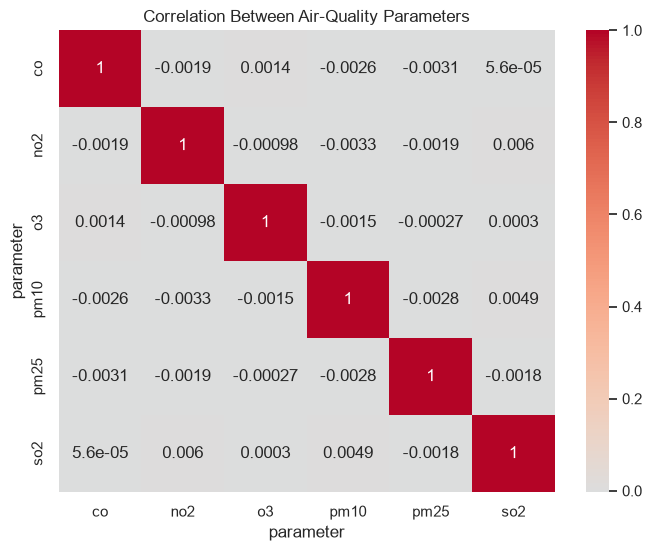

In [59]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Air-Quality Parameters")

plt.show()

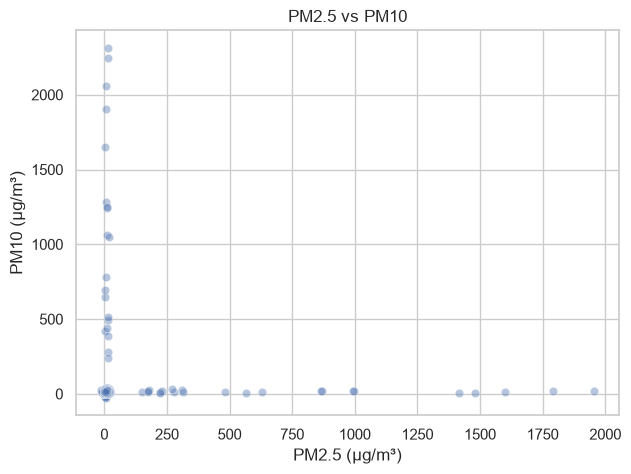

In [60]:
if "pm25" in pollutant_wide.columns and "pm10" in pollutant_wide.columns:
    
    plt.figure(figsize=(7, 5))
    
    sns.scatterplot(
        data=pollutant_wide,
        x="pm25",
        y="pm10",
        alpha=0.4
    )
    
    plt.title("PM2.5 vs PM10")
    plt.xlabel("PM2.5 (µg/m³)")
    plt.ylabel("PM10 (µg/m³)")
    
    plt.show()

In [61]:
for parameter in df["parameter"].unique():
    
    print(f"\nTop observations for {parameter.upper()}")
    
    temp = df[df["parameter"] == parameter]
    
    display(
        temp[
            [
                "location_name",
                "sensor_id",
                "datetime_utc",
                "value"
            ]
        ]
        .sort_values("value", ascending=False)
        .head(10)
    )


Top observations for O3


,location_name,sensor_id,datetime_utc,value
2141,Melbourne - CBD,S0003,2026-08-07 15:00:00+00:00,6919.00
4053,Brisbane - South,S0005,2026-08-06 04:00:00+00:00,6268.00
14556,Darwin - Palmerston,S0020,2026-08-11 14:00:00+00:00,5520.00
4111,Brisbane - South,S0005,2026-08-07 09:00:00+00:00,4168.00
12677,Hobart - New Town,S0017,2026-08-17 08:00:00+00:00,1906.97
10584,Canberra - Civic,S0014,2026-08-15 21:00:00+00:00,1832.12
7859,Perth - Swanbourne,S0010,2026-08-15 06:00:00+00:00,1486.48
9864,Adelaide - Netley,S0013,2026-08-14 22:00:00+00:00,1267.44
10246,Canberra - Civic,S0014,2026-08-08 20:00:00+00:00,1118.58
15012,Darwin - Palmerston,S0020,2026-08-17 22:00:00+00:00,1039.96



Top observations for NO2


,location_name,sensor_id,datetime_utc,value
15923,Darwin - Palmerston,S0021,2026-08-16 12:00:00+00:00,3020.00
7289,Perth - Swanbourne,S0009,2026-08-17 10:00:00+00:00,2998.00
15707,Darwin - Palmerston,S0021,2026-08-13 12:00:00+00:00,2845.00
7403,Perth - Swanbourne,S0009,2026-08-19 19:00:00+00:00,2541.00
15530,Darwin - Palmerston,S0021,2026-08-11 01:00:00+00:00,2092.00
9593,Adelaide - Netley,S0013,2026-08-09 06:00:00+00:00,1989.00
5715,Brisbane - South,S0007,2026-08-12 17:00:00+00:00,871.75
7373,Perth - Swanbourne,S0009,2026-08-19 04:00:00+00:00,826.31
10980,Canberra - Civic,S0015,2026-08-10 02:00:00+00:00,809.39
9799,Adelaide - Netley,S0013,2026-08-13 13:00:00+00:00,804.99



Top observations for PM25


...

,location_name,sensor_id,datetime_utc,value
11149,Canberra - Civic,S0015,2026-08-13 14:00:00+00:00,927.00
9368,Adelaide - Netley,S0012,2026-08-18 15:00:00+00:00,840.00
6365,Perth - Swanbourne,S0008,2026-08-12 05:00:00+00:00,727.00
6543,Perth - Swanbourne,S0008,2026-08-15 22:00:00+00:00,299.00
9072,Adelaide - Netley,S0012,2026-08-12 11:00:00+00:00,197.58
6607,Perth - Swanbourne,S0008,2026-08-17 06:00:00+00:00,190.36
13883,Hobart - New Town,S0019,2026-08-14 09:00:00+00:00,181.79
3620,Melbourne - CBD,S0004,2026-08-14 03:00:00+00:00,139.17
15313,Darwin - Palmerston,S0021,2026-08-08 01:00:00+00:00,89.00
11385,Canberra - Civic,S0015,2026-08-18 12:00:00+00:00,16.01



Top observations for PM10


,location_name,sensor_id,datetime_utc,value
16059,Darwin - Palmerston,S0021,2026-08-18 10:00:00+00:00,2314.0
15558,Darwin - Palmerston,S0021,2026-08-11 11:00:00+00:00,2247.0
8603,Adelaide - Netley,S0011,2026-08-16 17:00:00+00:00,2058.0
8347,Adelaide - Netley,S0011,2026-08-11 09:00:00+00:00,1906.0
13196,Hobart - New Town,S0018,2026-08-14 03:00:00+00:00,1650.0
1816,Sydney - Rozelle,S0002,2026-08-17 04:00:00+00:00,1282.0
4112,Brisbane - South,S0005,2026-08-07 10:00:00+00:00,1249.0
4106,Brisbane - South,S0005,2026-08-07 07:00:00+00:00,1243.0
7002,Perth - Swanbourne,S0009,2026-08-11 11:00:00+00:00,1062.0
7192,Perth - Swanbourne,S0009,2026-08-15 10:00:00+00:00,1051.0



Top observations for CO


,location_name,sensor_id,datetime_utc,value
2937,Melbourne - CBD,S0003,2026-08-18 17:00:00+00:00,67445.00
5836,Brisbane - South,S0007,2026-08-15 06:00:00+00:00,36924.00
14699,Darwin - Palmerston,S0020,2026-08-13 13:00:00+00:00,34873.00
8869,Adelaide - Netley,S0012,2026-08-08 05:00:00+00:00,30043.00
5658,Brisbane - South,S0007,2026-08-11 13:00:00+00:00,29271.00
2112,Melbourne - CBD,S0003,2026-08-07 06:00:00+00:00,26618.00
13069,Hobart - New Town,S0018,2026-08-11 11:00:00+00:00,14559.00
14939,Darwin - Palmerston,S0020,2026-08-16 21:00:00+00:00,12528.87
2979,Melbourne - CBD,S0003,2026-08-19 07:00:00+00:00,11712.00
8839,Adelaide - Netley,S0012,2026-08-07 14:00:00+00:00,11685.84


In [62]:
daily_max = (
    df.set_index("datetime_utc")
      .groupby(["parameter"])
      ["value"]
      .resample("D")
      .max()
      .reset_index()
)

daily_max.head()

,parameter,datetime_utc,value
0,co,2026-08-06 00:00:00+00:00,11583.93
1,co,2026-08-07 00:00:00+00:00,26618.00
2,co,2026-08-08 00:00:00+00:00,30043.00
3,co,2026-08-09 00:00:00+00:00,925.39
4,co,2026-08-10 00:00:00+00:00,9716.91


In [63]:
for parameter in daily_max["parameter"].unique():
    
    temp = daily_max[
        daily_max["parameter"] == parameter
    ]
    
    print(f"\nHighest daily values for {parameter.upper()}")
    
    display(
        temp.sort_values("value", ascending=False).head(10)
    )


Highest daily values for CO


,parameter,datetime_utc,value
12,co,2026-08-18 00:00:00+00:00,67445.00
9,co,2026-08-15 00:00:00+00:00,36924.00
7,co,2026-08-13 00:00:00+00:00,34873.00
2,co,2026-08-08 00:00:00+00:00,30043.00
5,co,2026-08-11 00:00:00+00:00,29271.00
1,co,2026-08-07 00:00:00+00:00,26618.00
10,co,2026-08-16 00:00:00+00:00,12528.87
13,co,2026-08-19 00:00:00+00:00,11712.00
0,co,2026-08-06 00:00:00+00:00,11583.93
4,co,2026-08-10 00:00:00+00:00,9716.91



Highest daily values for NO2


,parameter,datetime_utc,value
25,no2,2026-08-16 00:00:00+00:00,3020.00
26,no2,2026-08-17 00:00:00+00:00,2998.00
22,no2,2026-08-13 00:00:00+00:00,2845.00
28,no2,2026-08-19 00:00:00+00:00,2541.00
20,no2,2026-08-11 00:00:00+00:00,2092.00
18,no2,2026-08-09 00:00:00+00:00,1989.00
21,no2,2026-08-12 00:00:00+00:00,871.75
19,no2,2026-08-10 00:00:00+00:00,809.39
27,no2,2026-08-18 00:00:00+00:00,792.35
23,no2,2026-08-14 00:00:00+00:00,554.31



Highest daily values for O3


...

,parameter,datetime_utc,value
57,pm10,2026-08-18 00:00:00+00:00,2314.00
50,pm10,2026-08-11 00:00:00+00:00,2247.00
55,pm10,2026-08-16 00:00:00+00:00,2058.00
53,pm10,2026-08-14 00:00:00+00:00,1650.00
56,pm10,2026-08-17 00:00:00+00:00,1282.00
46,pm10,2026-08-07 00:00:00+00:00,1249.00
54,pm10,2026-08-15 00:00:00+00:00,1051.00
58,pm10,2026-08-19 00:00:00+00:00,781.00
48,pm10,2026-08-09 00:00:00+00:00,645.00
47,pm10,2026-08-08 00:00:00+00:00,280.19



Highest daily values for PM25


,parameter,datetime_utc,value
71,pm25,2026-08-17 00:00:00+00:00,1956.00
70,pm25,2026-08-16 00:00:00+00:00,1791.00
65,pm25,2026-08-11 00:00:00+00:00,1599.00
67,pm25,2026-08-13 00:00:00+00:00,1479.00
68,pm25,2026-08-14 00:00:00+00:00,1415.00
62,pm25,2026-08-08 00:00:00+00:00,994.00
64,pm25,2026-08-10 00:00:00+00:00,631.00
66,pm25,2026-08-12 00:00:00+00:00,566.00
73,pm25,2026-08-19 00:00:00+00:00,482.00
60,pm25,2026-08-06 00:00:00+00:00,309.14



Highest daily values for SO2


,parameter,datetime_utc,value
82,so2,2026-08-13 00:00:00+00:00,927.00
87,so2,2026-08-18 00:00:00+00:00,840.00
81,so2,2026-08-12 00:00:00+00:00,727.00
84,so2,2026-08-15 00:00:00+00:00,299.00
86,so2,2026-08-17 00:00:00+00:00,190.36
83,so2,2026-08-14 00:00:00+00:00,181.79
77,so2,2026-08-08 00:00:00+00:00,89.00
80,so2,2026-08-11 00:00:00+00:00,14.27
75,so2,2026-08-06 00:00:00+00:00,14.22
79,so2,2026-08-10 00:00:00+00:00,13.77


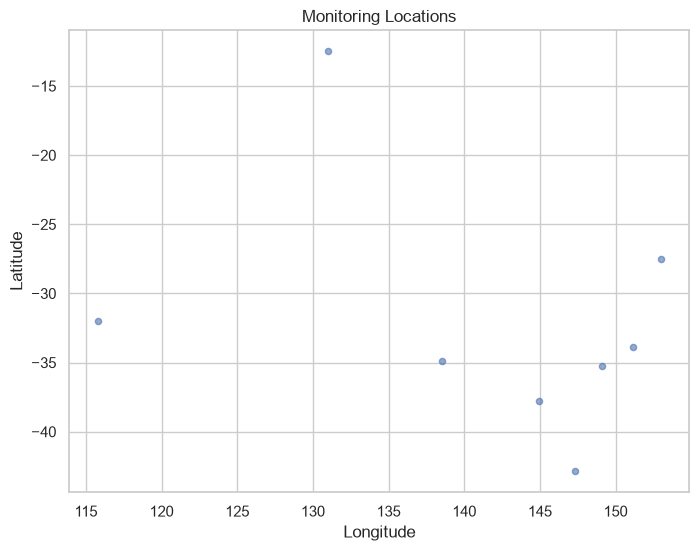

In [64]:
locations = (
    df[
        ["location_name", "lat", "lon"]
    ]
    .drop_duplicates()
)

plt.figure(figsize=(8, 6))

plt.scatter(
    locations["lon"],
    locations["lat"],
    s=20,
    alpha=0.6
)

plt.title("Monitoring Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()